# Predicting Fast-Growing Firms (2025)
Data Analysis 3 - Assignment 2  
Submitted by: Balint Decsi (ID: 2506626), Zariza Chowdhury (ID: 2500086)    
Deadline: 15 February 2026

## Objective
The objective of this assignment is to build and evaluate predictive models for identifying fast-growing firms using the Bisnode firms panel data.      
The analysis focuses on probability prediction, classification under an explicit loss function, and comparison of model performance across industries.

**Reproducibility and Project Structure**

This notebook is designed to be run from within the `Assignment-2/` directory.  
All file paths are specified as relative paths to ensure reproducibility across environments.  
Raw data, cleaned data, outputs, and reports follow a structured folder layout consistent with prior assignments.

## Modeling Overview and Target Choice

The fast-growth target used throughout this notebook is based on a one-year growth window (2013 vs 2012), defined as firms in the top decile of log sales growth over this period.      

This choice balances interpretability and sample size, while aligning with standard approaches in the corporate finance literature that emphasize short-horizon growth dynamics and mean reversion.

This notebook focuses on the modeling and evaluation stages of the analysis.        

## Task 1

Task 1 estimates and compares multiple predictive models for fast growth, first through probability prediction and then through classification under an explicit loss function.         

At least one parametric (logit) and one non-parametric (random forest) model are evaluated, with model selection based on cross-validated out-of-sample performance.

### Part I: Probability Prediction

This part estimates predictive models for the probability that a firm is fast-growing.      
Model performance is evaluated using cross-validation, and the preferred model is selected based on out-of-sample performance.

##### Step 1: Environment setup and imports

In [13]:
# Import necessary libraries and set up the environment
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import time

# Modeling + evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    make_scorer,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

In [2]:
# Define the paths (run from Assignment-2/)
base_dir = os.getcwd()

data_clean = os.path.join(base_dir, "Data", "Cleaned")
output_plots = os.path.join(base_dir, "Output", "Plots")
output_tables = os.path.join(base_dir, "Output", "Tables")

for p in [output_plots, output_tables]:
    os.makedirs(p, exist_ok=True)

data_clean, output_plots, output_tables

('/home/balintdecsi/repos/ceu/Data-Analysis-3/Assignment-2/Data/Cleaned',
 '/home/balintdecsi/repos/ceu/Data-Analysis-3/Assignment-2/Output/Plots',
 '/home/balintdecsi/repos/ceu/Data-Analysis-3/Assignment-2/Output/Tables')

In [3]:
# Helpers for clean overwrites (tables & figures)
def overwrite_csv(df, filepath, index=False):
    if os.path.exists(filepath):
        os.remove(filepath)
    df.to_csv(filepath, index=index)

def overwrite_fig(filepath):
    if os.path.exists(filepath):
        os.remove(filepath)

##### Step 2: Load the final modeling dataset

In [4]:
# Load final modeling dataset
model_path = os.path.join(data_clean, "bisnode_firms_clean.csv")
df = pd.read_csv(model_path)

print("Loaded dataset from:", model_path)
print("Dataset shape:", df.shape)

# Quick sanity check
df["fast_growth"].value_counts(normalize=True)

Loaded dataset from: /home/balintdecsi/repos/ceu/Data-Analysis-3/Assignment-2/Data/Cleaned/bisnode_firms_clean.csv
Dataset shape: (19135, 123)


fast_growth
0    0.899974
1    0.100026
Name: proportion, dtype: float64

##### Step 3: Define the target and feature set

Separate the target variable (`fast_growth`) from the predictors and remove identifiers and outcome-year fields to avoid leakage.

In [5]:
# Define X and y
y = df["fast_growth"].astype(int)

# Drop identifiers + target + outcome-year variables (avoid leakage)
drop_cols = [
    "comp_id", "year",
    "fast_growth",
    "growth_log_2013_2012",
    "sales_2013", "sales_mil_2013", "sales_mil_log_2013",
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Drop columns that are entirely missing (causes imputer warnings)
all_missing_cols = X.columns[X.isna().all()].tolist()

print("All-missing columns dropped:", all_missing_cols)

X = X.drop(columns=all_missing_cols)

# Recompute column lists after dropping
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("X shape:", X.shape)
print("Number of numeric features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))
print("Fast-growth rate:", y.mean())

cat_cols[:10]

All-missing columns dropped: ['D']
X shape: (19135, 115)
Number of numeric features: 106
Number of categorical features: 9
Fast-growth rate: 0.10002613012803763


['begin',
 'end',
 'gender',
 'origin',
 'region_m',
 'founded_date',
 'exit_date',
 'gender_m',
 'm_region_loc']

##### Step 4: Build the preprocessing pipeline

Create a reusable preprocessing pipeline:       
- numeric variables are imputed with the mean      
- categorical variables are imputed with the most frequent value and one-hot encoded

In [6]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

##### Choosing Candidate Models

To evaluate different approaches to probability prediction, I estimate three complementary models.  

- A standard logit with L2 regularization provides a transparent parametric baseline.
- A logit with L1 (LASSO) regularization allows for automatic feature selection in a high-dimensional setting.
- Finally, a random forest captures non-linearities and interactions without requiring explicit specification, serving as a flexible non-parametric benchmark.

##### Step 5: Baseline Probability Model (Logit) with Cross-Validation

Start with a transparent baseline model to predict fast-growth probabilities.       
A logit provides interpretability and a benchmark for more flexible models.

In [7]:
# Logit (L2) baseline + CV

# Start timer
start_time = time.time()

# 5-fold stratified CV (fixed seed for reproducibility)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic regression with L2 regularization
logit_l2 = LogisticRegression(
    penalty="l2",
    solver="saga",
    max_iter=5000,
    n_jobs=-1
)

# Pipeline: preprocessing + model
logit_l2_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", logit_l2),
])

# Cross-validated predicted probabilities
logit_l2_proba = cross_val_predict(
    logit_l2_pipe,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Runtime
runtime_l2 = time.time() - start_time

# Performance metrics
logit_l2_metrics = pd.DataFrame([{
    "model": "Logit (L2)",
    "roc_auc": roc_auc_score(y, logit_l2_proba),
    "avg_precision": average_precision_score(y, logit_l2_proba),
    "log_loss": log_loss(y, logit_l2_proba),
    "brier": brier_score_loss(y, logit_l2_proba),
    "runtime_sec": runtime_l2
}])

logit_l2_metrics

,model,roc_auc,avg_precision,log_loss,brier,runtime_sec
0,Logit (L2),0.752956,0.268563,0.432965,0.120592,78.749626


##### Step 6: Random Forest model (CV probability prediction)

This step fits a random forest classifier and evaluates out-of-sample probability prediction using the same 5-fold stratified cross-validation and metrics as the logit baseline.

In [8]:
# Random Forest + CV evaluation

# Start timer
start_time = time.time()

# Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# Pipeline: preprocessing + model
rf_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", rf_model),
])

# Cross-validated predicted probabilities
rf_proba = cross_val_predict(
    rf_pipe,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Runtime
runtime_rf = time.time() - start_time

# Performance metrics
rf_metrics = pd.DataFrame([{
    "model": "Random Forest",
    "roc_auc": roc_auc_score(y, rf_proba),
    "avg_precision": average_precision_score(y, rf_proba),
    "log_loss": log_loss(y, rf_proba),
    "brier": brier_score_loss(y, rf_proba),
    "runtime_sec": runtime_rf
}])

rf_metrics

,model,roc_auc,avg_precision,log_loss,brier,runtime_sec
0,Random Forest,0.827658,0.460406,0.274625,0.078067,4.277216


##### Step 7: LASSO Logit (L1) model (CV probability prediction)

This step fits a sparsity-inducing logit model (L1 regularization) as a third benchmark and evaluates probability prediction using the same cross-validation setup and metrics.

In [12]:
# LASSO Logit (L1)/ LASSO

# Start timer
start_time = time.time()

# Logistic regression with L1 regularization (sparse model)
logit_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    n_jobs=-1
)

# Pipeline: preprocessing + model
logit_l1_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", logit_l1),
])

# Cross-validated predicted probabilities
logit_l1_proba = cross_val_predict(
    logit_l1_pipe,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Runtime
runtime_l1 = time.time() - start_time

# Performance metrics
logit_l1_metrics = pd.DataFrame([{
    "model": "Logit (L1 / LASSO)",
    "roc_auc": roc_auc_score(y, logit_l1_proba),
    "avg_precision": average_precision_score(y, logit_l1_proba),
    "log_loss": log_loss(y, logit_l1_proba),
    "brier": brier_score_loss(y, logit_l1_proba),
    "runtime_sec": runtime_l1
}])

logit_l1_metrics

KeyboardInterrupt: 

##### Step 8: Model comparison (horserace)

This step combines cross-validated performance metrics across the three candidate models to support model selection for the classification task.

In [10]:
# Step 8: Combine CV results (horserace table)
horserace = pd.concat([logit_l2_metrics, rf_metrics, logit_l1_metrics], ignore_index=True)

# Sort by ROC-AUC (primary), then runtime (secondary)
horserace = horserace.sort_values(["roc_auc", "runtime_sec"], ascending=[False, True]).reset_index(drop=True)

# Save table
overwrite_csv(
    horserace,
    os.path.join(output_tables, "task1_part1_horserace_cv_metrics.csv")
)

horserace

NameError: name 'logit_l1_metrics' is not defined

##### Final Model Selection

The three models differ substantially in both predictive performance and computational cost.  
The random forest achieves the highest ROC–AUC and average precision, indicating superior ability to rank firms by fast-growth probability and to identify fast growers in an imbalanced setting. It also performs well in terms of log loss and Brier score, suggesting better-calibrated probabilities.

Both logit models (L2 and L1) perform similarly to each other but significantly worse than the random forest across all predictive metrics. While the L1-regularized logit offers automatic feature selection, it comes at a very high computational cost without improving predictive performance relative to the simpler L2 logit.

Overall, the random forest dominates the parametric alternatives by delivering stronger out-of-sample performance at a fraction of the runtime, making it the preferred model for probability prediction in this task.

## Task 1 Part II: Classification

We define a loss function based on the business problem.
Assuming that missing a fast-growing firm (False Negative) is more costly than falsely identifying one (False Positive),
we set the cost of FN to be 4 times the cost of FP.

We assume: FP Cost = 1, FN Cost = 4.

We then evaluate the models (Logit L2 and Random Forest) by finding the optimal threshold that minimizes expected loss for each fold in the cross-validation.


In [14]:
# Define Loss function
FP_COST = 1
FN_COST = 4
cost_ratio = FN_COST / FP_COST

models = {
    'Logit (L2)': logit_l2_pipe,
    'Random Forest': rf_pipe
}

results_part2 = []
fold5_vars = {} # To store fold 0 data for Part 3

print(f'Loss Function: FP={FP_COST}, FN={FN_COST}')

for name, model in models.items():
    print(f'Evaluating {name}...')
    fold_losses = []
    fold_threshs = []
    
    # Iterate folds using the same CV object
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate optimal threshold
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        N = len(y_test)
        N_pos = y_test.sum()
        N_neg = N - N_pos
        loss_values = (fpr * N_neg * FP_COST + (1 - tpr) * N_pos * FN_COST) / N
        best_idx = np.argmin(loss_values)
        
        best_t = thresholds[best_idx]
        min_l = loss_values[best_idx]
        
        fold_losses.append(min_l)
        fold_threshs.append(best_t)
        
        # Store Fold 0 data for RF for Part 3
        if fold_idx == 0 and name == 'Random Forest':
             fold5_vars['y_test'] = y_test
             fold5_vars['y_pred'] = y_pred_proba
             fold5_vars['thresh'] = best_t

    avg_loss = np.mean(fold_losses)
    avg_thresh = np.mean(fold_threshs)
    
    results_part2.append({
        'model': name,
        'avg_expected_loss': avg_loss,
        'avg_optimal_threshold': avg_thresh
    })

results_df = pd.DataFrame(results_part2)
overwrite_csv(results_df, os.path.join(output_tables, 'cv_metrics_classification.csv'))
results_df


Loss Function: FP=1, FN=4
Evaluating Logit (L2)...
Evaluating Random Forest...


,model,avg_expected_loss,avg_optimal_threshold
0,Logit (L2),0.315652,0.446369
1,Random Forest,0.254926,0.150121


## Task 1 Part III: Discussion of Results

We present the confusion matrix for the Random Forest model (on one validation fold) using the optimal threshold derived above.


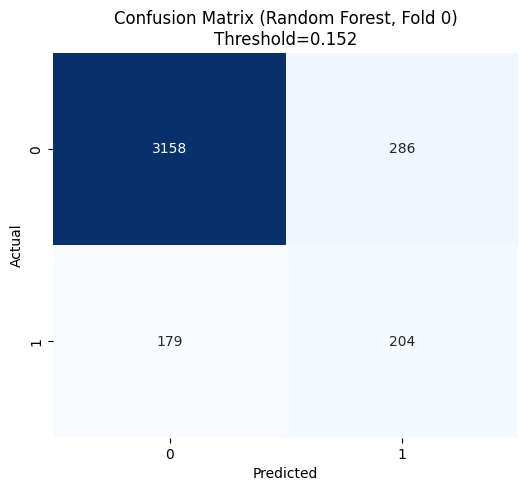

In [15]:
# Confusion Matrix for Random Forest (Fold 0)
y_test_plot = fold5_vars['y_test']
y_pred_plot = fold5_vars['y_pred']
thresh_plot = fold5_vars['thresh']

y_pred_class = (y_pred_plot >= thresh_plot).astype(int)
cm = confusion_matrix(y_test_plot, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Random Forest, Fold 0)\nThreshold={thresh_plot:.3f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(os.path.join(output_plots, 'confusion_matrix_rf.png'))
plt.show()


## Task 2: Industry Differences

We compare model performance across two broad industry categories:
- **Manufacturing** (ind2_cat < 33)
- **Services** (ind2_cat in {33, 55, 56}, covering repair, accommodation, food)

We retrain and evaluate the Random Forest model separately for each group.


In [16]:
# Task 2: Industry Split
# Define Categories
X_manuf = X[X['ind2_cat'] < 33].copy()
y_manuf = y[X['ind2_cat'] < 33].copy()

X_serv = X[X['ind2_cat'].isin([33, 55, 56])].copy()
y_serv = y[X['ind2_cat'].isin([33, 55, 56])].copy()

print(f'Manufacturing firms: {len(X_manuf)}')
print(f'Services firms: {len(X_serv)}')

task2_results = []

# Use RF (rf_pipe)
for group_name, (X_g, y_g) in [('Manufacturing', (X_manuf, y_manuf)), ('Services', (X_serv, y_serv))]:
    print(f'Running on {group_name}...')
    
    fold_aucs = []
    fold_losses = []
    
    # New CV for the subset
    cv_g = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, test_idx in cv_g.split(X_g, y_g):
        X_tr, X_te = X_g.iloc[train_idx], X_g.iloc[test_idx]
        y_tr, y_te = y_g.iloc[train_idx], y_g.iloc[test_idx]
        
        # Clone pipe to reset
        from sklearn.base import clone
        model_g = clone(rf_pipe)
        
        model_g.fit(X_tr, y_tr)
        probs = model_g.predict_proba(X_te)[:, 1]
        
        # AUC
        fold_aucs.append(roc_auc_score(y_te, probs))
        
        # Loss
        fpr, tpr, thresholds = roc_curve(y_te, probs)
        N = len(y_te)
        N_pos = y_te.sum()
        N_neg = N - N_pos
        loss_values = (fpr * N_neg * FP_COST + (1 - tpr) * N_pos * FN_COST) / N
        min_l = np.min(loss_values)
        fold_losses.append(min_l)

    task2_results.append({
        'industry': group_name,
        'avg_auc': np.mean(fold_aucs),
        'avg_expected_loss': np.mean(fold_losses),
        'n_firms': len(X_g)
    })

task2_df = pd.DataFrame(task2_results)
overwrite_csv(task2_df, os.path.join(output_tables, 'industry_comparison.csv'))
task2_df


Manufacturing firms: 4064
Services firms: 14656
Running on Manufacturing...
Running on Services...


,industry,avg_auc,avg_expected_loss,n_firms
0,Manufacturing,0.816598,0.238920,4064
1,Services,0.837621,0.257232,14656
